In [2]:
import subprocess
subprocess.run(['pip', 'install', 'pandas', 'numpy',
                'matplotlib', 'seaborn', 'plotly', 'openpyxl'],
                capture_output=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

print("All Libraries Ready!")

All Libraries Ready!


In [4]:
import os
df = pd.read_csv('Nassau_Candy_Distributor.csv', encoding='latin1')
print(f"Dataset Loaded!")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print(f"Columns: {df.columns.tolist()}")
df.head()

Dataset Loaded!
Rows: 10194, Columns: 18
Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Country/Region', 'City', 'State/Province', 'Postal Code', 'Division', 'Region', 'Product ID', 'Product Name', 'Sales', 'Units', 'Gross Profit', 'Cost']


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [12]:
print("Cleaning Started...")

df['Order Date']   = pd.to_datetime(df['Order Date'],   errors='coerce')
df['Ship Date']    = pd.to_datetime(df['Ship Date'],    errors='coerce')
df['Sales']        = pd.to_numeric(df['Sales'],         errors='coerce')
df['Cost']         = pd.to_numeric(df['Cost'],          errors='coerce')
df['Gross Profit'] = pd.to_numeric(df['Gross Profit'],  errors='coerce')
df['Units']        = pd.to_numeric(df['Units'],         errors='coerce')

before = len(df)
df = df[df['Sales'] > 0]
df = df.dropna(subset=['Sales', 'Cost', 'Gross Profit'])
print(f"Removed {before - len(df)} invalid rows")

df['Units']        = df['Units'].fillna(df['Units'].median())
df['Division']     = df['Division'].str.strip().str.title()
df['Product Name'] = df['Product Name'].str.strip()

df.to_csv('nassau_candy_cleaned.csv', index=False)

print(f"Clean Rows : {len(df)}")
print(f"Divisions  : {df['Division'].unique()}")
print(f"Products   : {df['Product Name'].nunique()}")
print("Saved Nassau Candy Distributor cleaned.csv")

Cleaning Started...
Removed 0 invalid rows
Clean Rows : 10194
Divisions  : <ArrowStringArray>
['Chocolate', 'Other', 'Sugar']
Length: 3, dtype: str
Products   : 15
Saved Nassau Candy Distributor cleaned.csv


In [13]:
df['Gross Margin (%)']         = (df['Gross Profit'] / df['Sales'] * 100).round(2)
df['Profit per Unit']          = (df['Gross Profit'] / df['Units']).round(2)
df['Revenue Contribution (%)'] = (df['Sales'] / df['Sales'].sum() * 100).round(4)
df['Profit Contribution (%)']  = (df['Gross Profit'] / df['Gross Profit'].sum() * 100).round(4)

def margin_risk(m):
    if m < 15:   return 'High Risk'
    elif m < 30: return 'Medium Risk'
    else:        return 'Low Risk'

df['Margin Risk'] = df['Gross Margin (%)'].apply(margin_risk)

print("KPIs Calculated!")
print(f"Total Revenue    : ${df['Sales'].sum():,.2f}")
print(f"Total Profit     : ${df['Gross Profit'].sum():,.2f}")
print(f"Avg Gross Margin : {df['Gross Margin (%)'].mean():.2f}%")
print(f"Total Units Sold : {int(df['Units'].sum()):,}")
df[['Product Name', 'Gross Margin (%)', 'Profit per Unit', 'Margin Risk']].head(5)


KPIs Calculated!
Total Revenue    : $141,783.63
Total Profit     : $93,442.80
Avg Gross Margin : 66.51%
Total Units Sold : 38,654


[5]

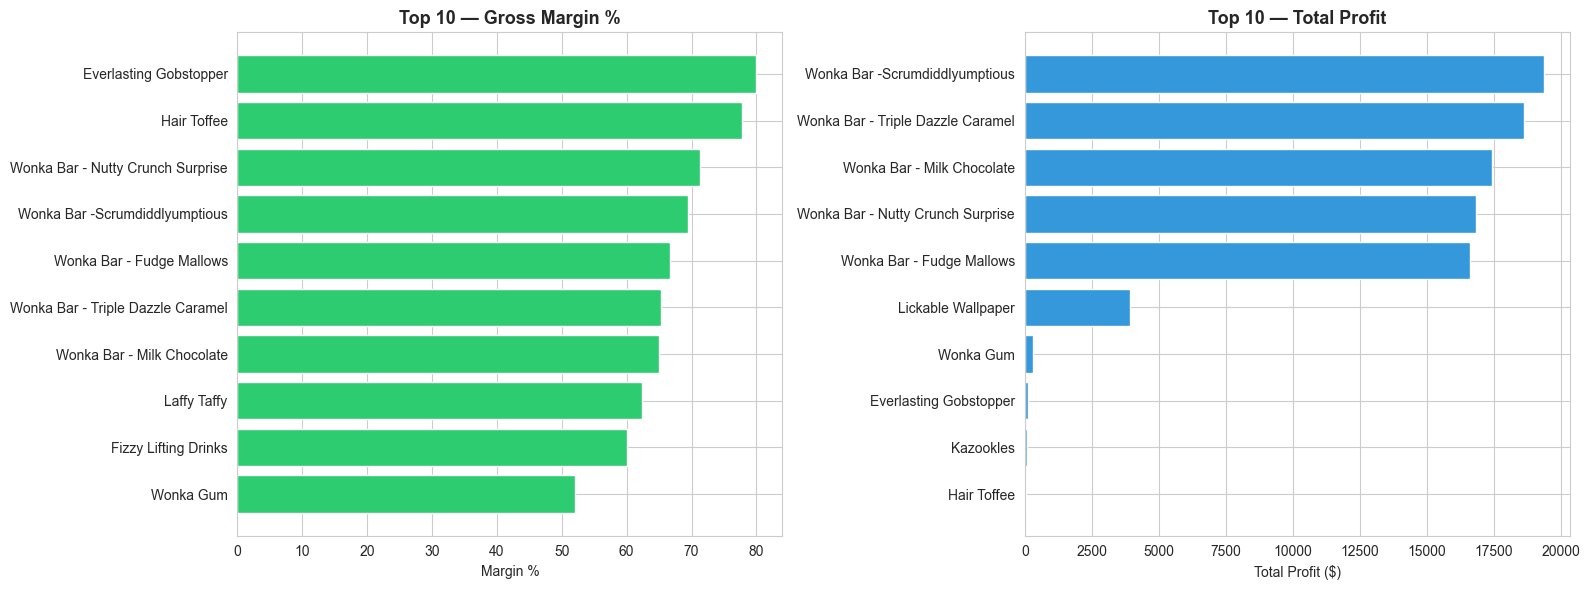

Chart saved!


In [14]:
prod = df.groupby(['Product Name', 'Division']).agg(
    Total_Sales  = ('Sales',            'sum'),
    Total_Profit = ('Gross Profit',     'sum'),
    Total_Cost   = ('Cost',             'sum'),
    Total_Units  = ('Units',            'sum'),
    Avg_Margin   = ('Gross Margin (%)', 'mean'),
    Orders       = ('Order ID',         'nunique')
).reset_index()

prod['Profit per Unit']      = (prod['Total_Profit'] / prod['Total_Units']).round(2)
prod['Revenue Contribution'] = (prod['Total_Sales']  / prod['Total_Sales'].sum()  * 100).round(2)
prod['Profit Contribution']  = (prod['Total_Profit'] / prod['Total_Profit'].sum() * 100).round(2)

prod_by_margin = prod.sort_values('Avg_Margin', ascending=False)
prod_by_profit = prod.sort_values('Total_Profit', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top10  = prod_by_margin.head(10)
colors = ['#2ecc71' if m >= 30 else '#f39c12' if m >= 15 else '#e74c3c'
          for m in top10['Avg_Margin']]
axes[0].barh(top10['Product Name'], top10['Avg_Margin'], color=colors)
axes[0].set_title('Top 10 — Gross Margin %', fontsize=13, fontweight='bold')
axes[0].invert_yaxis()
axes[0].set_xlabel('Margin %')

axes[1].barh(prod_by_profit.head(10)['Product Name'],
             prod_by_profit.head(10)['Total_Profit'], color='#3498db')
axes[1].set_title('Top 10 — Total Profit', fontsize=13, fontweight='bold')
axes[1].invert_yaxis()
axes[1].set_xlabel('Total Profit ($)')

plt.tight_layout()
plt.savefig('product_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")


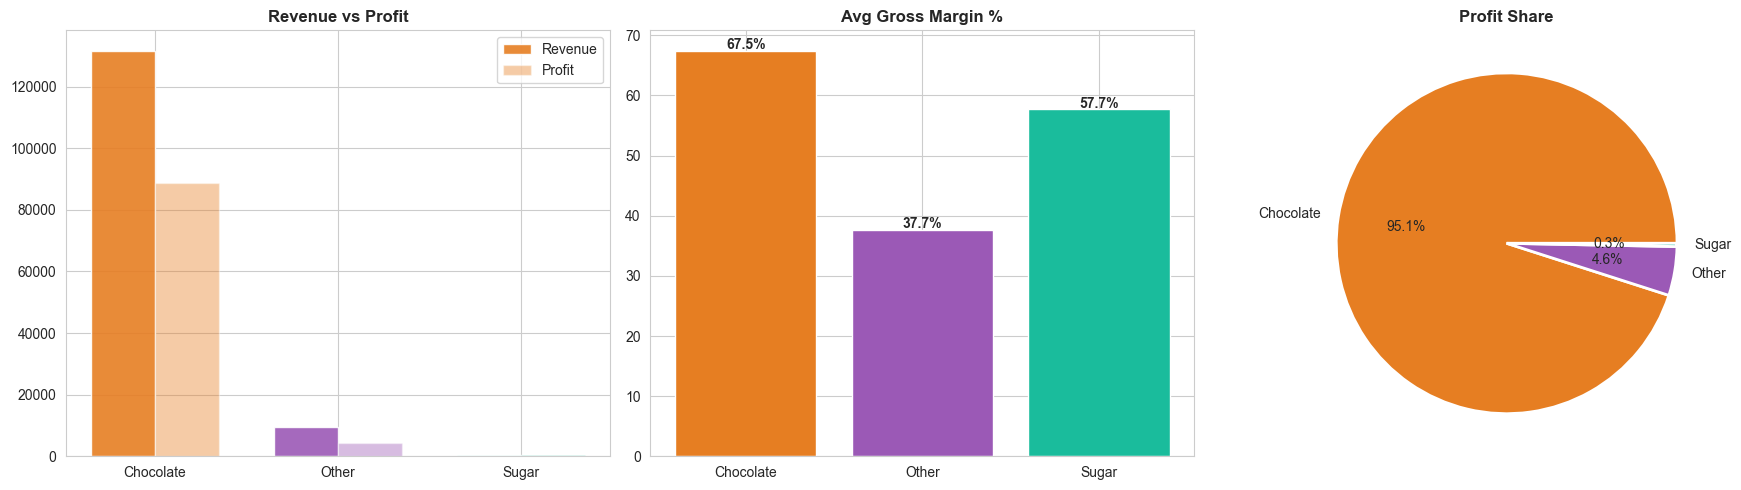

 Division   Revenue   Profit  Avg_Margin
Chocolate 131692.90 88824.62   67.457102
    Other   9663.25  4333.45   37.671742
    Sugar    427.48   284.73   57.690000


In [15]:
div = df.groupby('Division').agg(
    Revenue    = ('Sales',            'sum'),
    Profit     = ('Gross Profit',     'sum'),
    Avg_Margin = ('Gross Margin (%)', 'mean'),
    Products   = ('Product Name',     'nunique'),
    Orders     = ('Order ID',         'nunique')
).reset_index()

div_colors = ['#e67e22', '#9b59b6', '#1abc9c']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

x, w = np.arange(len(div)), 0.35
axes[0].bar(x-w/2, div['Revenue'], w, color=div_colors, alpha=0.9, label='Revenue')
axes[0].bar(x+w/2, div['Profit'],  w, color=div_colors, alpha=0.4, label='Profit')
axes[0].set_xticks(x)
axes[0].set_xticklabels(div['Division'])
axes[0].set_title('Revenue vs Profit', fontweight='bold')
axes[0].legend()

bars = axes[1].bar(div['Division'], div['Avg_Margin'], color=div_colors)
axes[1].set_title('Avg Gross Margin %', fontweight='bold')
for bar, val in zip(bars, div['Avg_Margin']):
    axes[1].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+0.3, f'{val:.1f}%', ha='center', fontweight='bold')

axes[2].pie(div['Profit'], labels=div['Division'],
            autopct='%1.1f%%', colors=div_colors,
            wedgeprops={'edgecolor':'white', 'linewidth':2})
axes[2].set_title('Profit Share', fontweight='bold')

plt.tight_layout()
plt.savefig('division_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print(div[['Division', 'Revenue', 'Profit', 'Avg_Margin']].to_string(index=False))

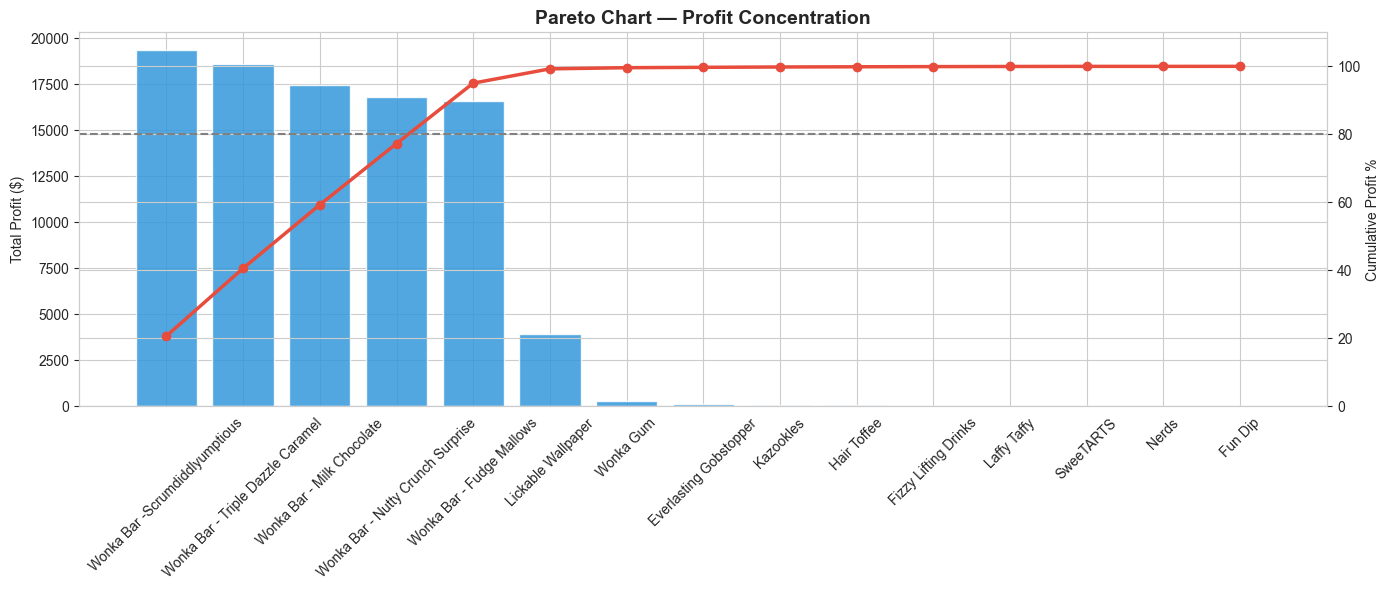

5 products → 80% of Total Profit!


In [16]:
pareto = prod.sort_values('Total_Profit', ascending=False).copy()
pareto['Cumulative Profit %'] = (
    pareto['Total_Profit'].cumsum() / pareto['Total_Profit'].sum() * 100
).round(2)

n_80       = pareto[pareto['Cumulative Profit %'] >= 80].iloc[0].name
n_80_count = list(pareto.index).index(n_80) + 1

fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.bar(pareto['Product Name'], pareto['Total_Profit'],
        color='#3498db', alpha=0.85)
ax1.set_ylabel('Total Profit ($)')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.plot(pareto['Product Name'], pareto['Cumulative Profit %'],
         color='#e74c3c', marker='o', linewidth=2.5)
ax2.axhline(80, color='gray', linestyle='--', label='80% Line')
ax2.set_ylabel('Cumulative Profit %')
ax2.set_ylim(0, 110)

plt.title('Pareto Chart — Profit Concentration', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('pareto.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"{n_80_count} products → 80% of Total Profit!")


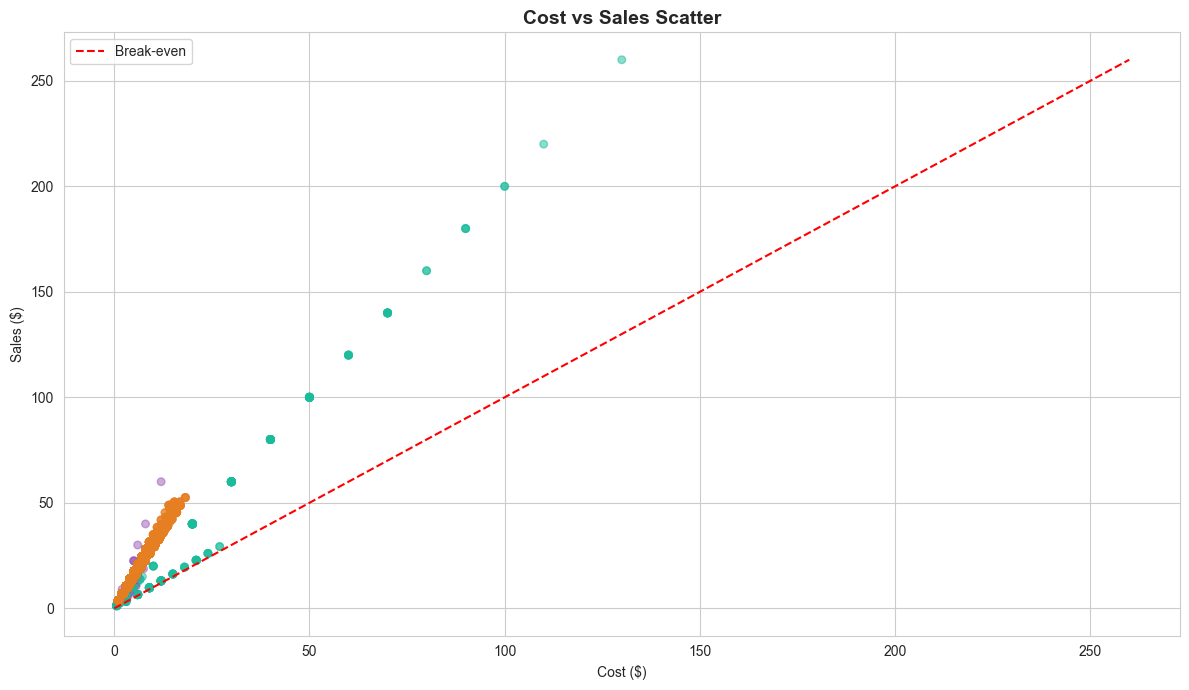

RISK FLAG TABLE:
                     Product Name  Division  Avg_Margin Risk              Action
                        Kazookles     Other        7.69 HIGH Discontinue/Reprice
                          Fun Dip     Sugar       40.00  LOW    Maintain & Scale
                            Nerds     Sugar       46.67  LOW    Maintain & Scale
                        SweeTARTS     Sugar       46.67  LOW    Maintain & Scale
               Lickable Wallpaper     Other       50.00  LOW    Maintain & Scale
                        Wonka Gum     Other       52.00  LOW    Maintain & Scale
             Fizzy Lifting Drinks     Sugar       60.00  LOW    Maintain & Scale
                      Laffy Taffy     Sugar       62.31  LOW    Maintain & Scale
       Wonka Bar - Milk Chocolate Chocolate       64.92  LOW    Maintain & Scale
Wonka Bar - Triple Dazzle Caramel Chocolate       65.33  LOW    Maintain & Scale
        Wonka Bar - Fudge Mallows Chocolate       66.67  LOW    Maintain & Scale
   Wonka Ba

In [17]:
fig, ax = plt.subplots(figsize=(12, 7))

div_color_map = {'Chocolate':'#e67e22', 'Sugar':'#9b59b6', 'Other':'#1abc9c'}
colors_s      = df['Division'].map(div_color_map).fillna('#95a5a6')

ax.scatter(df['Cost'], df['Sales'], c=colors_s, alpha=0.5, s=30)
max_val = max(df['Sales'].max(), df['Cost'].max())
ax.plot([0, max_val], [0, max_val], 'r--', label='Break-even')
ax.set_xlabel('Cost ($)')
ax.set_ylabel('Sales ($)')
ax.set_title('Cost vs Sales Scatter', fontsize=14, fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('cost_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

print("RISK FLAG TABLE:")
risk_df           = prod[['Product Name', 'Division', 'Avg_Margin']].copy()
risk_df['Risk']   = risk_df['Avg_Margin'].apply(
    lambda m: 'HIGH'   if m < 15 else 'MEDIUM' if m < 30 else 'LOW')
risk_df['Action'] = risk_df['Avg_Margin'].apply(
    lambda m: 'Discontinue/Reprice' if m < 15 else
              'Cost Renegotiation'   if m < 30 else 'Maintain & Scale')
print(risk_df.sort_values('Avg_Margin').to_string(index=False))

 Handle Missing Units 

In [6]:
df['Units'] = df['Units'].fillna(df['Units'].median())
print(f"Missing Units after fix: {df['Units'].isna().sum()}")

Missing Units after fix: 0


Standardize Labels

In [9]:
df['Division'] = df['Division'].str.strip().str.title()
df['Product Name'] = df['Product Name'].str.strip()
print("Labels Standardized")

Labels Standardized


 Over-Dependency Risk

In [11]:
pareto = df.groupby('Product Name')['Gross Profit'].sum().sort_values(ascending=False)
pareto_df = pareto.reset_index()
pareto_df['Cum%'] = (pareto_df['Gross Profit'].cumsum() / pareto_df['Gross Profit'].sum() * 100).round(2)
top80 = pareto_df[pareto_df['Cum%'] <= 80]
print(f"\n Over-Dependency: Top {len(top80)} products = 80% of profit!")


 Over-Dependency: Top 4 products = 80% of profit!
